# ABSA-FMI: Lexicon-Based Aspect Labeling




In [ ]:
# Setup
!pip install gensim -q

import re, json, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
from collections import defaultdict, Counter

SEED = 42
np.random.seed(SEED)

try:
    from google.colab import files
    import os
    if not os.path.exists('dataset_ulasan.xlsx') and not os.path.exists('dataset_labeled_v5.xlsx'):
        print("Silakan unggah berkas dataset (.xlsx):")
        files.upload()
except ImportError:
    print("[INFO] Bukan lingkungan Colab — pastikan berkas ada di folder kerja.")

print("[OK] Cell 1 selesai")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.5 MB/s eta 0:00:00
Silakan unggah berkas dataset (.xlsx):


Saving dataset_filtered.xlsx to dataset_filtered.xlsx
[OK] Cell 1 selesai


In [ ]:
# Load data
import os

KANDIDAT = ['dataset_filtered.xlsx', 'dataset_ulasan.xlsx', 'dataset.xlsx',
            'dataset_labeled_v5.xlsx']
BERKAS = next((f for f in KANDIDAT if os.path.exists(f)), None)
if BERKAS is None:
    xls = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.csv'))]
    if not xls:
        raise FileNotFoundError(
            "Tidak ada berkas .xlsx/.csv di folder kerja.\n"
            "Unggah dataset ulasan Anda lewat panel Files di sebelah kiri.")
    BERKAS = xls[0]
print(f"[OK] Memakai berkas: {BERKAS}")

df = pd.read_excel(BERKAS) if BERKAS.endswith('.xlsx') else pd.read_csv(BERKAS)

if 'ulasan' not in df.columns:
    kand = [c for c in df.columns if c.lower() in
            ('ulasan','review','komentar','comment','comments','text','teks','content','isi')]
    if not kand:
        raise KeyError(f"Kolom teks tidak ditemukan. Kolom tersedia: {list(df.columns)}")
    df = df.rename(columns={kand[0]: 'ulasan'})
if 'rating' not in df.columns:
    kand = [c for c in df.columns if c.lower() in
            ('rating','ratings','bintang','star','stars','score','nilai','skor')]
    df = df.rename(columns={kand[0]: 'rating'}) if kand else df.assign(rating=np.nan)

df['ulasan'] = df['ulasan'].astype(str)
df = df[df['ulasan'].str.strip().ne('') & df['ulasan'].str.lower().ne('nan')].reset_index(drop=True)

print(f"     jumlah ulasan : {len(df):,}")
print(f"     kolom         : {list(df.columns)[:8]}")
if df['rating'].notna().any():
    print(f"     sebaran rating: {dict(df['rating'].value_counts().sort_index())}")
pjg = df['ulasan'].str.split().str.len()
print(f"     panjang teks  : median {pjg.median():.0f} kata, p95 {pjg.quantile(.95):.0f}, maks {pjg.max()}")
print("\n     contoh:")
for t in df['ulasan'].head(3):
    print(f"       {t[:95]!r}")
print(f"\n     [PENTING] row_id gold mengacu pada urutan baris dataset ini (0..{len(df)-1}).")
print("               Jangan menyaring/mengurutkan ulang df setelah sel ini.")
print("\n[OK] Cell 2 selesai")

[OK] Memakai berkas: dataset_filtered.xlsx
     jumlah ulasan : 6,158
     kolom         : ['Username', 'rating', 'Date', 'ulasan']
     sebaran rating: {1.0: np.int64(149), 2.0: np.int64(98), 3.0: np.int64(224), 4.0: np.int64(530), 5.0: np.int64(5136)}
     panjang teks  : median 10 kata, p95 32, maks 138

     contoh:
       'Styling:Skena banget lah Compass nih\nKenyamanan:nyaman banget empuk kalau sizingnya pas\n\nBaru m'
       'Tampilan:sesuai keinginan\nWarna:Sesuai dengan gambar\n\nBeli tanggal 26, tanggal 27 udah sampe ke'
       'Styling:kata cowoku bagus\nKenyamanan:kata cowoku empuk sepatunya\nKualitas:katanya juga bagus\n\nJ'

     [PENTING] row_id gold mengacu pada urutan baris dataset ini (0..6157).
               Jangan menyaring/mengurutkan ulang df setelah sel ini.

[OK] Cell 2 selesai


## Cell 4 — LDA Aspect Validation



[1/6] Praproses ...
      dokumen valid : 6,070
[2/6] Bigram & trigram (NPMI) ...
[3/6] Kamus & bag-of-words ...
      kosakata: 363 | dokumen BoW: 5,974
[4/6] Coherence K=2..13 - tiga metrik (perlu beberapa menit) ...
      C_v mudah menggelembung saat kosakata mengecil, karena itu
      c_npmi dan u_mass dilaporkan berdampingan sebagai pembanding.

        K       C_v    c_npmi    u_mass


        2    0.2777   -0.0025   -3.5255


        3    0.3490   -0.0105   -4.2744
        4    0.3725    0.0177   -3.9572
        5    0.3675   -0.0063   -4.3483
        6    0.3708    0.0068   -4.4144  <- dipakai
        7    0.3882    0.0005   -5.0028
        8    0.3870    0.0008   -5.0162
        9    0.3530   -0.0361   -5.7505
       10    0.3735   -0.0215   -5.4967
       11    0.3622   -0.0490   -6.2461
       12    0.3739   -0.0768   -6.9878
       13    0.3449   -0.0723   -6.8102

      C_v tertinggi : K=7 (0.3882)
      C_v pada K=6  : 0.3708  (selisih 0.0174)
      sebaran C_v pada K=5..11: 0.0352

[5/6] Melatih model final K=6 ...
      kosakata acuan per aspek: {'kualitas': 24, 'bahan': 37, 'ukuran': 14, 'desain': 31, 'warna': 35, 'kenyamanan': 45}

  MATRIKS OVERLAP BERBOBOT (topik x aspek)
  rank 1-5 = x3, rank 6-15 = x2, rank 16-30 = x1
  topik   kualitas   bahan      ukuran     desain     warna      kenyamana  
  T0      0          0          9          0          2          1          
  T1      1          22

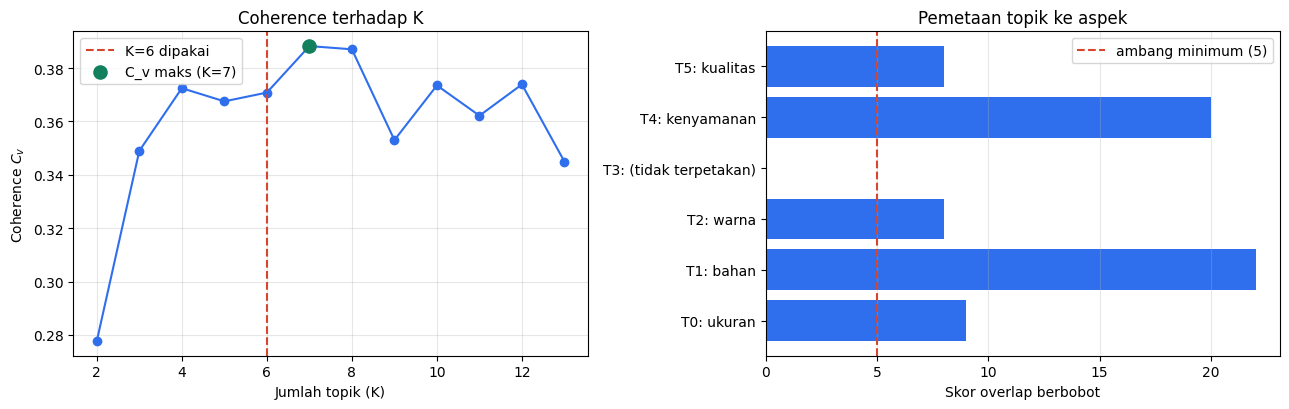


  KESIMPULAN — dasar pemilihan 6 aspek
  1. Coherence pada K=5..11 hanya bervariasi 0.0352, sehingga tidak
     diskriminatif. K=6 dipilih atas dasar interpretabilitas, bukan
     karena C_v tertinggi (C_v maks ada di K=7).
  2. 6/6 aspek memiliki kehadiran topikal berarti -> mendukung skema 6 aspek.
  3. 5/6 topik terpetakan satu-satu dengan ambang 5.
     Keterbatasan: desain tidak membentuk topik tersendiri.
  4. Stabilitas: 2/5 seed memberi hasil pemetaan yang sama lengkapnya.
  5. Pembanding model: LDA c_npmi=0.0066, GSDMM=0.0329, NMF=-0.0201
     Gabungan LDA+GSDMM memulihkan 6/6 aspek.

  LDA di sini MEMVALIDASI granularitas aspek. Pelabelan tiap ulasan
  dilakukan oleh sistem leksikon pada Cell 5-6, bukan oleh LDA.

[OK] Ringkasan: {'k_dipakai': 6, 'cv_k6': 0.3708, 'k_optimal': 7, 'cv_optimal': 0.3882, 'sebaran_k5_11': 0.0352, 'aspek_hadir': 6, 'topik_terpetakan': 5, 'seed_konsisten': 2, 'cnpmi_k6': 0.0068, 'umass_k6': -4.4144, 'aspek_gabungan': 6}


In [ ]:
# LDA aspect validation
import re, warnings, numpy as np, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Nmf
from gensim.models.phrases import Phrases


class GSDMM:
    def __init__(self, K=6, alpha=0.1, beta=0.1, n_iter=12, seed=42):
        self.K, self.alpha, self.beta, self.n_iter = K, alpha, beta, n_iter
        self.rng = np.random.RandomState(seed)
    def fit(self, docs, V):
        K, D = self.K, len(docs)
        m_z, n_z = np.zeros(K), np.zeros(K)
        n_zw = np.zeros((K, V))
        d_z = self.rng.randint(0, K, D)
        for d, z in enumerate(d_z):
            m_z[z] += 1; n_z[z] += len(docs[d])
            for w in docs[d]: n_zw[z, w] += 1
        for _ in range(self.n_iter):
            for d, doc in enumerate(docs):
                z = d_z[d]; m_z[z] -= 1; n_z[z] -= len(doc)
                for w in doc: n_zw[z, w] -= 1
                cnt = {}
                for w in doc: cnt[w] = cnt.get(w, 0) + 1
                logp = np.log(m_z + self.alpha)
                for k in range(K):
                    s = 0.0
                    for w, c in cnt.items():
                        for j in range(c): s += np.log(n_zw[k, w] + self.beta + j)
                    for i in range(len(doc)): s -= np.log(n_z[k] + V * self.beta + i)
                    logp[k] += s
                p = np.exp(logp - logp.max()); p /= p.sum()
                z = self.rng.choice(K, p=p)
                d_z[d] = z; m_z[z] += 1; n_z[z] += len(doc)
                for w in doc: n_zw[z, w] += 1
        self.n_zw = n_zw
        return self
    def top_words(self, k, id2word, topn=30):
        idx = np.argsort(-self.n_zw[k])[:topn]
        return [id2word[i] for i in idx if self.n_zw[k, i] > 0]

SEED_UTAMA = 42
K_TARGET   = 6

STOPWORDS_LDA = {
    "yang","dan","di","ke","dari","untuk","dengan","adalah","ini","itu",
    "atau","juga","sudah","telah","akan","bisa","ada","tidak","ga","gak",
    "nggak","ngga","tdk","gk","tak","enggak","saya","aku","kamu","dia",
    "kami","kita","mereka","ya","aja","sih","nih","deh","dong","lah",
    "tapi","tp","yg","bgt","banget","bngt","jadi","kalau","kalo",
    "karena","karna","sama","buat","lebih","lagi","udah","udh",
    "sangat","sekali","amat","terlalu","mau","mo","pakai","pake",
    "an","by","to","in","is","it","the","of","with",
    "oke","ok","good","nice","bad","puas","kecewa","mantap","mantul",
    "recommended","rekomendasi",
    "seller","penjual","pengiriman","kirim","kurir","packing","kemasan",
    "respon","admin","tokopedia","shopee","lazada","jnt","jne","sicepat",
    "barang","produk","pesanan","orderan","beli","order","beneran","emang",
    "erigo","erigo_official","erigo_store","brand","merk","merek","nya",
    "terimakasih","makasih","thx","thanks","thank","semoga","moga",
    "mudah","barokah","berkah","rezeki","aamiin","amiin",
    "kali","tiap","setiap","hampir","sering","pernah",
    "disini","sini","sana","situ","sono","dimana","mana",
    "wah","wow","duh","aduh","nah","haha","hehe","woah",
    "hingga","sampai","agar","supaya","jika","bila","andai",
    "meski","meskipun","walau","walaupun","sehingga","ketika","waktu",
    "atas","bawah","depan","belakang","kiri","kanan","tengah",
    "baru","lama","dulu","coba","harus","perlu","butuh",
}
POST_BIGRAM_STOPWORDS = {"bagus", "jelek"}

def _nc(t):
    return re.sub(r'(.)\1{2,}', r'\1\1', t)

def preprocess_lda(text):
    if not isinstance(text, str) or not text.strip():
        return []
    t = _nc(text.lower())
    t = re.sub(r'http\S+|www\S+', '', t)
    t = re.sub(r'\d+', '', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    tok = [w for w in t.split() if len(w) >= 3]
    return [w for w in tok if w not in STOPWORDS_LDA]

print("[1/6] Praproses ...")
raw = [preprocess_lda(str(t)) for t in df['ulasan']]
raw = [t for t in raw if len(t) >= 2]
print(f"      dokumen valid : {len(raw):,}")

print("[2/6] Bigram & trigram (NPMI) ...")
bg = Phrases(raw, min_count=max(3, int(len(raw)*0.005)), threshold=0.3, scoring='npmi').freeze()
korpus_bg = [[w for w in bg[d] if w not in POST_BIGRAM_STOPWORDS] for d in raw]
tg = Phrases(korpus_bg, min_count=max(2, int(len(raw)*0.003)), threshold=0.3, scoring='npmi').freeze()
korpus = [[w for w in tg[bg[d]] if w not in POST_BIGRAM_STOPWORDS] for d in raw]

print("[3/6] Kamus & bag-of-words ...")
kamus = corpora.Dictionary(korpus)
kamus.filter_extremes(no_below=max(2, int(len(korpus)*0.004)), no_above=0.70, keep_n=8000)
bow_all = [kamus.doc2bow(t) for t in korpus]
bow   = [b for b in bow_all if b]
teks  = [t for t, b in zip(korpus, bow_all) if b]
print(f"      kosakata: {len(kamus):,} | dokumen BoW: {len(bow):,}")

def latih(k, seed=SEED_UTAMA, passes=10):
    return LdaModel(corpus=bow, id2word=kamus, num_topics=k, random_state=seed,
                    passes=passes, alpha='auto', eta='auto', iterations=100, chunksize=2000)

print("[4/6] Coherence K=2..13 - tiga metrik (perlu beberapa menit) ...")
print("      C_v mudah menggelembung saat kosakata mengecil, karena itu")
print("      c_npmi dan u_mass dilaporkan berdampingan sebagai pembanding.")
K_RANGE, skor, skor_npmi, skor_umass = list(range(2, 14)), [], [], []
print(f"\n      {'K':>3}{'C_v':>10}{'c_npmi':>10}{'u_mass':>10}")
for k in K_RANGE:
    _m = latih(k)
    _t = [[w for w, _ in _m.show_topic(t, topn=20)] for t in range(k)]
    cv = CoherenceModel(topics=_t, texts=teks, dictionary=kamus, coherence='c_v').get_coherence()
    npmi = CoherenceModel(topics=_t, texts=teks, dictionary=kamus, coherence='c_npmi').get_coherence()
    um = CoherenceModel(topics=_t, texts=teks, dictionary=kamus, corpus=bow, coherence='u_mass').get_coherence()
    skor.append(cv); skor_npmi.append(npmi); skor_umass.append(um)
    tanda = "  <- dipakai" if k == K_TARGET else ""
    print(f"      {k:>3}{cv:>10.4f}{npmi:>10.4f}{um:>10.4f}{tanda}")
s = skor[K_RANGE.index(K_TARGET)]

k_opt   = K_RANGE[int(np.argmax(skor))]
s_opt   = max(skor)
s_target = skor[K_RANGE.index(K_TARGET)]
rentang = max(skor[3:10]) - min(skor[3:10])     # K=5..11
print(f"\n      C_v tertinggi : K={k_opt} ({s_opt:.4f})")
print(f"      C_v pada K={K_TARGET}  : {s_target:.4f}  (selisih {abs(s_opt-s_target):.4f})")
print(f"      sebaran C_v pada K=5..11: {rentang:.4f}")
if rentang < 0.02:
    print("      -> Kurva datar: koherensi TIDAK diskriminatif pada rentang ini,")
    print("         sehingga K=6 dapat dipertahankan atas dasar interpretabilitas.")

print("\n[5/6] Melatih model final K=6 ...")
lda_model = latih(K_TARGET, passes=20)

# Reference vocabulary per aspect
KATA_DASAR = {
 "kualitas":  {"kualitas","jahit","jahitan","ori","original","realpict","cacat",
               "rusak","benang","obras","lecet","konsistensi","sesuai"},
 "bahan":     {"bahan","kain","material","katun","cotton","polyester","spandex",
               "linen","fleece","lembut","halus","kasar","tebal","tipis",
               "tekstur","fabric","serat","combed"},
 "ukuran":    {"ukuran","size","fit","kekecilan","kebesaran","sempit","longgar",
               "ketat","oversize","upsize","muat","kegedean"},
 "desain":    {"desain","design","model","motif","tampilan","style","styling",
               "potongan","cutting","siluet","bordir","sablon","modis","trendy",
               "kasual","formal","minimalis","elegan","kece","simple"},
 "warna":     {"warna","color","hitam","putih","merah","biru","hijau","kuning",
               "abu","coklat","cream","pink","ungu","navy","maroon","tosca",
               "olive","cerah","pekat","gelap","pudar","luntur"},
 "kenyamanan":{"nyaman","kenyamanan","comfortable","adem","enak","empuk","panas",
               "gerah","gatal","risih","sesak","berat","ringan","dipakai",
               "dipake","sejuk"},
}
_vocab = set(kamus.token2id)
ASPECT_REF = {}
for _a, _b in KATA_DASAR.items():
    _s = set(_b)
    for _v in _vocab:
        if any(_w in _b for _w in _v.split('_')):
            _s.add(_v)
    ASPECT_REF[_a] = _s
print("      kosakata acuan per aspek:", {a: len(v) for a, v in ASPECT_REF.items()})

AMBANG_MIN = 5      # di bawah ini, topik dianggap TIDAK terpetakan

def auto_map(model, n_words=30, ambang=AMBANG_MIN):
    """Pemetaan topik->aspek dengan bobot rank. Bisa GAGAL (mengembalikan
    '(tidak terpetakan)') bila bukti overlap-nya lemah."""
    tw = {t: model.show_topic(t, topn=n_words) for t in range(model.num_topics)}
    def sk(t, ref):
        s = 0
        for rank, (w, _) in enumerate(tw[t]):
            if w in ref:
                s += 3 if rank < 5 else 2 if rank < 15 else 1
        return s
    M = {(t, a): sk(t, r) for t in tw for a, r in ASPECT_REF.items()}
    peta, sisa_t, sisa_a = {}, set(tw), set(ASPECT_REF)
    while sisa_t and sisa_a:
        t, a = max(((t, a) for t in sisa_t for a in sisa_a), key=lambda x: M[x])
        if M[(t, a)] < ambang:
            break                       # <- inilah yang membuat validasi bisa gagal
        peta[t] = (a, M[(t, a)]); sisa_t.discard(t); sisa_a.discard(a)
    for t in sisa_t:
        peta[t] = ("(tidak terpetakan)", 0)
    return peta, M

peta, M = auto_map(lda_model)
aspek_list = list(ASPECT_REF)

print("\n" + "="*72)
print("  MATRIKS OVERLAP BERBOBOT (topik x aspek)")
print("  rank 1-5 = x3, rank 6-15 = x2, rank 16-30 = x1")
print("="*72)
print("  " + "topik".ljust(8) + "".join(a[:9].ljust(11) for a in aspek_list))
for t in range(K_TARGET):
    print("  " + f"T{t}".ljust(8) + "".join(str(M[(t, a)]).ljust(11) for a in aspek_list))

# Analysis A: aspect coverage
print("\n" + "="*72)
print("  ANALISIS A — CAKUPAN ASPEK")
print("  Apakah setiap aspek punya kehadiran topikal yang berarti?")
print("="*72)
cakupan = {}
for a in aspek_list:
    t_terbaik = max(range(K_TARGET), key=lambda t: M[(t, a)])
    cakupan[a] = (t_terbaik, M[(t_terbaik, a)])
    kata = [w for w, _ in lda_model.show_topic(t_terbaik, topn=30) if w in ASPECT_REF[a]][:6]
    status = "kuat" if M[(t_terbaik, a)] >= 8 else "sedang" if M[(t_terbaik, a)] >= 5 else "lemah"
    print(f"  {a:<12} skor tertinggi {M[(t_terbaik,a)]:>3} di T{t_terbaik}  [{status}]")
    print(f"  {'':<12} kata: {', '.join(kata) if kata else '-'}")
n_hadir = sum(1 for _, sk in cakupan.values() if sk >= 5)
print(f"\n  {n_hadir}/6 aspek memiliki kehadiran topikal yang berarti (skor >= 5).")

# Analysis B: one-to-one topic mapping
print("\n" + "="*72)
print("  ANALISIS B — PEMETAAN SATU-SATU (syarat ketat)")
print(f"  Penetapan greedy dengan ambang minimum {AMBANG_MIN};")
print("  topik yang buktinya lemah sengaja DIBIARKAN tidak terpetakan.")
print("="*72)
for t in sorted(peta):
    a, sk = peta[t]
    kata = ", ".join(w for w, _ in lda_model.show_topic(t, topn=8))
    print(f"  T{t} -> {a:<22} skor {sk:>2}")
    print(f"  {'':<6} {kata}")
terpetakan = sum(1 for v in peta.values() if v[0] != "(tidak terpetakan)")
tak_dapat = sorted(set(aspek_list) - {v[0] for v in peta.values()})
print(f"\n  {terpetakan}/{K_TARGET} topik terpetakan.")
if tak_dapat:
    print(f"  Aspek yang TIDAK menguasai topik mana pun: {', '.join(tak_dapat)}")
    print("  Artinya kosakata aspek tersebut tersebar di beberapa topik dan")
    print("  tidak membentuk topik tersendiri. Laporkan ini apa adanya sebagai")
    print("  keterbatasan; jangan diperbaiki dengan menambah kata acuan sampai cocok.")

print("\n" + "="*72)
print("  PEMBANDING MODEL TOPIK (K=6)")
print("  LDA   : campuran topik per dokumen")
print("  NMF   : faktorisasi matriks non-negatif")
print("  GSDMM : satu topik per dokumen, dirancang untuk teks pendek")
print("="*72)

def tiga_metrik(topics):
    out = {}
    for nama in ['c_v', 'c_npmi', 'u_mass']:
        try:
            out[nama] = CoherenceModel(topics=topics, texts=teks, dictionary=kamus,
                                       corpus=bow, coherence=nama).get_coherence()
        except Exception:
            out[nama] = float('nan')
    return out

topik_lda = [[w for w, _ in lda_model.show_topic(t, topn=20)] for t in range(K_TARGET)]
nmf_model = Nmf(corpus=bow, id2word=kamus, num_topics=K_TARGET, random_state=SEED_UTAMA, passes=20)
topik_nmf = [[w for w, _ in nmf_model.show_topic(t, topn=20)] for t in range(K_TARGET)]
_ids = [[kamus.token2id[w] for w in x if w in kamus.token2id] for x in teks]
_ids = [x for x in _ids if x]
gsdmm_model = GSDMM(K=K_TARGET, n_iter=12, seed=SEED_UTAMA).fit(_ids, len(kamus))
topik_gsdmm = [gsdmm_model.top_words(k, kamus, topn=20) for k in range(K_TARGET)]

print(f"\n  {'model':<10}{'c_v':>10}{'c_npmi':>10}{'u_mass':>10}")
BANDING = {}
for nama, tp in [('LDA', topik_lda), ('NMF', topik_nmf), ('GSDMM', topik_gsdmm)]:
    r = tiga_metrik(tp); BANDING[nama] = r
    print(f"  {nama:<10}{r['c_v']:>10.4f}{r['c_npmi']:>10.4f}{r['u_mass']:>10.4f}")

def petakan(topics30):
    tw = {i: t for i, t in enumerate(topics30)}
    sc = lambda i, r: sum(3 if j < 5 else 2 if j < 15 else 1
                          for j, w in enumerate(tw[i]) if w in r)
    M = {(i, a): sc(i, ASPECT_REF[a]) for i in tw for a in ASPECT_REF}
    p, st, sa = {}, set(tw), set(ASPECT_REF)
    while st and sa:
        i, a = max(((i, a) for i in st for a in sa), key=lambda z: M[z])
        if M[(i, a)] < AMBANG_MIN: break
        p[i] = a; st.discard(i); sa.discard(a)
    return set(p.values())

asp_lda = petakan([[w for w, _ in lda_model.show_topic(t, topn=30)] for t in range(K_TARGET)])
asp_gs  = petakan([gsdmm_model.top_words(k, kamus, topn=30) for k in range(K_TARGET)])
print(f"\n  Aspek yang dipulihkan:")
print(f"    LDA   : {len(asp_lda)}/6  {sorted(asp_lda)}")
print(f"    GSDMM : {len(asp_gs)}/6  {sorted(asp_gs)}")
gabung, iris = asp_lda | asp_gs, asp_lda & asp_gs
print(f"    gabungan  : {len(gabung)}/6  {sorted(gabung)}")
print(f"    irisan    : {len(iris)}/6  {sorted(iris)}")
if len(gabung) == 6:
    print("\n  -> Dua model dengan ASUMSI BERBEDA sama-sama memulihkan aspek,")
    print("     dan gabungannya menutup keenam aspek. Konvergensi lintas")
    print("     keluarga model ini bukti yang lebih kuat daripada satu model saja.")
lemah = sorted(gabung - iris)
if lemah:
    print(f"  -> Aspek yang TIDAK dipulihkan kedua model: {', '.join(lemah)}")
    print("     Aspek ini bertanda leksikal paling lemah pada korpus.")
    print("     Periksa apakah selaras dengan aspek ber-kappa anotator terendah;")
    print("     bila ya, dua bukti independen menunjuk kesimpulan yang sama.")

print("\n[6/6] Uji stabilitas lintas random_state ...")
stabil = {}
for sd in [42, 7, 123, 2024, 99]:
    p, _ = auto_map(latih(K_TARGET, seed=sd, passes=10))
    stabil[sd] = sorted(v[0] for v in p.values() if v[0] != "(tidak terpetakan)")
    print(f"      seed {sd:>4}: {len(stabil[sd])}/6 topik terpetakan -> {', '.join(stabil[sd])}")
_acuan = stabil[SEED_UTAMA]
konsisten = sum(1 for v in stabil.values() if set(v) == set(_acuan))
print(f"\n      {konsisten} dari 5 seed memberi himpunan aspek yang sama dengan seed utama.")
print("      Angka ini WAJIB dilaporkan: LDA pada teks pendek memang tidak stabil,")
print("      dan pembaca berhak tahu seberapa kokoh pemetaannya.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(K_RANGE, skor, 'o-', color='#2f6fed')
ax[0].axvline(K_TARGET, ls='--', c='#d8452f', label=f'K={K_TARGET} dipakai')
ax[0].scatter([k_opt], [s_opt], c='#12805c', zorder=5, s=90, label=f'C_v maks (K={k_opt})')
ax[0].set_xlabel('Jumlah topik (K)'); ax[0].set_ylabel('Coherence $C_v$')
ax[0].set_title('Coherence terhadap K'); ax[0].legend(); ax[0].grid(alpha=.3)
nama = [peta[t][0] for t in range(K_TARGET)]
nilai = [peta[t][1] for t in range(K_TARGET)]
ax[1].barh([f'T{t}: {n}' for t, n in enumerate(nama)], nilai, color='#2f6fed')
ax[1].axvline(AMBANG_MIN, ls='--', c='#d8452f', label=f'ambang minimum ({AMBANG_MIN})')
ax[1].set_xlabel('Skor overlap berbobot'); ax[1].set_title('Pemetaan topik ke aspek')
ax[1].legend(); ax[1].grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()

LDA_RINGKASAN = dict(k_dipakai=K_TARGET, cv_k6=round(float(s_target),4),
                     k_optimal=k_opt, cv_optimal=round(float(s_opt),4),
                     sebaran_k5_11=round(float(rentang),4),
                     aspek_hadir=n_hadir, topik_terpetakan=terpetakan,
                     seed_konsisten=konsisten,
                     cnpmi_k6=round(float(skor_npmi[K_RANGE.index(K_TARGET)]),4),
                     umass_k6=round(float(skor_umass[K_RANGE.index(K_TARGET)]),4),
                     aspek_gabungan=len(gabung))
print("\n" + "="*72)
print("  KESIMPULAN — dasar pemilihan 6 aspek")
print("="*72)
print(f"  1. Coherence pada K=5..11 hanya bervariasi {rentang:.4f}, sehingga tidak")
print(f"     diskriminatif. K={K_TARGET} dipilih atas dasar interpretabilitas, bukan")
print(f"     karena C_v tertinggi (C_v maks ada di K={k_opt}).")
print(f"  2. {n_hadir}/6 aspek memiliki kehadiran topikal berarti -> mendukung skema 6 aspek.")
print(f"  3. {terpetakan}/6 topik terpetakan satu-satu dengan ambang {AMBANG_MIN}.")
if tak_dapat:
    print(f"     Keterbatasan: {', '.join(tak_dapat)} tidak membentuk topik tersendiri.")
print(f"  4. Stabilitas: {konsisten}/5 seed memberi hasil pemetaan yang sama lengkapnya.")
print(f"  5. Pembanding model: LDA c_npmi={BANDING['LDA']['c_npmi']:.4f}, "
      f"GSDMM={BANDING['GSDMM']['c_npmi']:.4f}, NMF={BANDING['NMF']['c_npmi']:.4f}")
print(f"     Gabungan LDA+GSDMM memulihkan {len(gabung)}/6 aspek.")
print("\n  LDA di sini MEMVALIDASI granularitas aspek. Pelabelan tiap ulasan")
print("  dilakukan oleh sistem leksikon pada Cell 5-6, bukan oleh LDA.")
print("\n[OK] Ringkasan:", LDA_RINGKASAN)

## Cell 5 — Lexicon and Labeling Function




In [ ]:
import re
# Aspect lexicon
ASPECT_LEXICON = {

    # quality
    "kualitas": [
        "kualitas", "quality", "kualiti",
        "realpict", "realpic", "real pict", "real pic",
        "sesuai gambar", "sesuai foto", "sesuai deskripsi",
        "sesuai iklan", "sesuai ekspektasi", "sesuai pesanan",
        "sesuai keinginan", "sesuai orderan",
        "beda dari foto", "beda dari gambar",
        "tidak sesuai gambar", "ga sesuai gambar",
        "ori", "original", "asli", "kw", "palsu", "tiruan",
        "cacat", "sobek", "robek", "retak", "rusak", "lecet",
        "jahit", "jahitan", "jahitannya", "dijahit",
        "jahit putus", "jahitan putus", "jahitan jelek",
        "jahitan lepas", "obras lepas", "obras",
        "benang", "benang keluar", "benang lepas", "benang nongol",
        "lubang", "bolong", "baret", "kotor",
        "konsistensi", "worth", "sepadan",
        "sesuai harga", "value for money",
        "recommended", "rekomendasi",
        "memuaskan", "puas", "kepuasan",
    ],

    # material
    "bahan": [
        "bahan", "material", "fabric", "kain", "serat",
        "katun", "cotton", "polyester", "spandex", "linen",
        "fleece", "terry", "combed", "denim", "suede",
        "kulit", "leather", "kanvas", "parasut",
        "lembut", "halus", "kasar", "kaku", "licin",
        "tekstur", "permukaan",
        "tebal", "tipis", "ketebalan",
        "stretch", "stretchy", "elastis", "melar",
        "breathable", "anti bau", "antibau",
        "luntur", "tidak luntur", "ga luntur",
    ],

    # size
    "ukuran": [
        "ukuran", "size", "sizing",
        "fit", "fitting", "ngefit",
        "pas di badan", "pas di tubuh", "cocok di badan",
        "kekecilan", "terlalu kecil", "sempit", "mepet",
        "kebesaran", "terlalu besar", "longgar", "kegedean",
        "ketat", "lebar", "muat",
        "up size", "upsize", "up 1 size", "naik size",
        "down size", "downsize", "turun size",
        "naikin size", "turunin size",
        "oversize", "oversized",
    ],

    "desain": [
        "desain", "design",
        "styling", "style", "fashion", "modis", "trendy",
        "tampilan", "penampilan", "tampak", "saran tampilan", "look",
        "motif", "pattern", "corak", "polos", "bergaris",
        "bordir", "sablon", "logo",
        "model", "bentuk", "siluet", "potongan", "cutting",
        "kece", "simple", "minimalis", "elegan",
        "kasual", "casual", "formal", "skena",
        "kalcer", "kalcer", "ganteng",
    ],

    "warna": [
        "warna", "color", "colour", "pewarnaan",
        "hitam", "putih", "merah", "biru", "hijau", "kuning",
        "abu", "abu-abu", "coklat", "cream", "krem", "pink",
        "ungu", "oranye", "orange", "maroon", "navy", "tosca",
        "olive", "sage", "mocca", "nude", "pastel",
        "pekat", "cerah", "gelap", "pucat", "pudar", "buram",
        "sesuai warna", "beda warna", "warna sesuai",
        "warna pudar", "warna luntur",
    ],

    "kenyamanan": [
        "kenyamanan", "comfortable", "comfort",
        "nyaman", "enak", "enak dipakai", "empuk",
        "adem", "panas", "gerah",
        "gatal", "gatel", "sakit", "risih", "sesak",
        "tidak nyaman", "ga nyaman", "kurang nyaman",
        "dipakai", "dipake", "saat dipakai",
        "berat", "ringan", "agak berat", "terlalu berat",
        "sangat ringan", "super ringan",
    ],
}

# Sentiment lexicon

POSITIVE_WORDS = {
    "bagus","baik","mantap","oke","ok","sip","jos","joss","josss",
    "puas","suka","love","senang","memuaskan","terbaik","best",
    "perfect","sempurna","amazing","wow","keren","cakep","kece",
    "recommended","rekomendasi","worth","good","nice","excellent",
    "mantul","yahud","lembut","halus","tebal","ringan","adem",
    "elastis","pas","fit","ngefit","cocok","muat",
    "pekat","cerah","nyaman","empuk","enak","aesthetic","estetik",
    "stylish","modis","menarik","cantik","lucu","unik",
    "aman","rapi","bersih","wangi","baguss","bagusss","lumayan",
    "mulus","tanpa masalah","tanpa kendala",
    "elegan", "elegant", "kalcer", "skena", "ganteng",
    "mevah", "mewah", "josjis", "josjiss", "jossjiss",
    "warbiyasak", "warbebes", "gilak", "gila",
    "jos", "kece", "cakeppp", "kereenn", "mantapp",
    "top", "oke", "sesuai", "cocok", "pas", "asik",
}

NEGATIVE_WORDS = {
    "jelek","buruk","kecewa","rugi","nyesal","mengecewakan",
    "parah","payah","hancur","kasar","kaku","licin","tipis",
    "kekecilan","kebesaran","ketat","sempit","longgar","mepet",
    "pudar","luntur","buram","panas","gerah","gatal","gatel",
    "sakit","risih","cacat","sobek","robek","retak",
    "rusak","lecet","baret","kotor","bolong",
    "jahitan jelek","jahitan lepas","benang keluar","benang lepas",
    "palsu","kw","beda dari foto","tidak sesuai gambar",
    "bosen","monoton","bad","kurang","tidak bagus","ga bagus",
    "berat",
}

NEGATABLE_NEGATIVE_WORDS = {
    "panas","gerah","gatal","gatel","sakit","risih",
    "kasar","kaku","tipis","longgar","sempit","ketat",
    "berat","pudar","luntur","bau","berbau",
    "jelek","buruk","mengecewakan","kecewa",
    "cacat","rusak","sobek","robek","retak","lecet",
    "kotor","baret","bolong","lubang",
    "masalah","kendala","kekurangan",
}

HARD_NEGATIVE_WORDS = {
    "kekecilan", "kebesaran", "kegedean",
    "luntur", "sobek", "cacat", "robek", "retak", "lecet",
    "kecewa", "mengecewakan", "nyesal", "rugi",
    "tipis",
    "pudar",
    "ancur", "ancurr",
}

HARD_NEGATIVE_PHRASES = {
    "terlalu kecil", "terlalu besar",
    "jahitan jelek", "jahitan lepas", "benang keluar",
    "tidak sesuai", "ga sesuai", "gak sesuai", "nggak sesuai",
    "warna pudar", "warna luntur",
    "tdk sesuai",
    "beda warna", "warna beda", "warna berbeda",
    "warna tidak sesuai",
    "tipis transparan", "agak tipis", "lumayan tipis",
    "cukup tipis", "sedikit tipis",
    "baju partai",      # kain murahan = negatif
    "gasesuai",         # "GASESUAIIIII" -> normalize -> gasesuai
    "gaksesuai",        # variasi
    "nggaksesuai",      # variasi
    "ga cocok", "gak cocok", "tidak cocok",
    "ga pantes", "tidak pantas",
    "kecewa banget", "kecewa bgt",
}

NEGATION_WORDS = {
    "tidak","ga","gak","tak","nggak","ngga",
    "belum","bukan","tanpa","tdk","gk","enggak",
}

INTENSIFIER_WORDS = {
    "banget","bgt","bngt","bgtt","sangat","sekali",
    "amat","terlalu","super","bener","beneran",
    "parah","abis","pol","sgt",
}

# Negated hard negative patterns
# quality
# quality
# quality
# color
NEGATED_HARD_NEGATIVE_RE = re.compile(
    r'\b(?:tidak|ga|gak|nggak|ngga|tak|tdk|gk|enggak)'
    r'\s+(?:pernah\s+)?(?:terlalu\s+)?'
    r'(?:mengecewakan|kecewa|buruk|gagal|jelek|mengecewa|kapok)\b',
    re.IGNORECASE
)

NEGATED_CONCAT_RE = re.compile(
    r'\b(?:gapernah|gakpernah|nggakpernah|ngapernah)'
    r'\s+(?:mengecewakan|kecewa|buruk|gagal|jelek)\b',
    re.IGNORECASE
)

# Expectation reversal patterns
EXPECTATION_REVERSAL_RE = re.compile(
    r'\b(?:kira[\-\s]?kira|kirain|kukira|dikira|sangka|awalnya\s+kira|'
    r'kirain\s+bakal|kukira\s+bakal|dikira\s+bakal)\b'
    r'.{0,60}'
    r'\b(?:kekecilan|kebesaran|kegedean|sempit|kecil|besar|jelek|kurang|tidak bagus)\b'
    r'.{0,60}'
    r'\b(?:ternyata|eh\s+ternyata|tapi\s+ternyata|tp\s+ternyata)\b'
    r'.{0,40}'
    r'\b(?:pas|oke|ok|sesuai|cocok|bagus|nyaman|fit|ngefit|enak|mantap)\b',
    re.IGNORECASE | re.DOTALL
)

_NEG_QUALITY_WORDS = (
    r'(?:cacat|rusak|sobek|robek|retak|lecet|kotor|baret'
    r'|bolong|lubang|masalah|kendala|kekurangan|keluhan'
    r'|tipis|pudar|luntur|ancur|ancurr)'
)
_FILLER_PATTERN = (
    r'(?:(?:terlalu|sangat|begitu|sekali|banget|bgt|ada|bikin'
    r'|membuat|bisa|jadi|ada\s+)\s+)*'
)
NEGATION_PHRASE_RE = re.compile(
    r'\b(?:tidak ada|ga ada|gak ada|nggak ada|ngga ada'
    r'|tanpa|tidak|ga|gak|nggak|tak|tdk|gk)\s+' + _FILLER_PATTERN + _NEG_QUALITY_WORDS,
    re.IGNORECASE
)

SESUAI_NEGATIVE_RE = re.compile(
    r'\b(?:tidak|ga|gak|nggak|ngga|tak|tdk|gk)\s+sesuai',
    re.IGNORECASE
)
SESUAI_POSITIVE_RE = re.compile(r'\bsesuai\b', re.IGNORECASE)

NON_ASPECT_WORDS = {
    "seller","admin","cs","penjual","pelayanan","layanan",
    "pengiriman","kirim","kiriman","kurir","ekspedisi",
    "jnt","jne","sicepat","anteraja","ninja","gosend","gojek","grab",
    "packing","packaging","kemasan","bungkus","dus","kardus",
    "box","plastik","bubble",
    "respon","respons","fast","reply","balas","komunikasi",
    "checkout","bayar","pembayaran","transfer","cod",
}

NON_PRODUCT_WORDS = {
    "bonus","free","gratis","hadiah","gift",
    "gantungan","tumblr","tumbler","totebag","stiker","sticker","kartu",
    "promo","diskon","discount","sale","flash",
    "voucher","kupon","cashback","poin","reward","koin",
    "live","siaran","livestream","event",
}

EMOJI_SENTIMENT_MAP = {
    # strong positive
    "\U0001f60d": "positif",   # 😍 Heart eyes
    "\U0001f970": "positif",   # 🥰 Smiling with hearts
    "\U0001f63b": "positif",   # 😻 Heart eyes cat
    "\U0001f929": "positif",   # 🤩 Star-struck
    "\U0001f618": "positif",   # 😘 Kissing heart
    "\U0001f44d": "positif",   # 👍 Thumbs up
    "\U0001f525": "positif",   # 🔥 Fire (keren/hits)
    "\U0001f4af": "positif",   # 💯 100%
    "\u2728":     "positif",   # ✨ Sparkles
    "\u2b50":     "positif",   # ⭐ Star
    "\u2764":     "positif",   # ❤ Heart
    "\U0001f497": "positif",   # 💗 Growing heart
    "\U0001f49d": "positif",   # 💝 Heart with ribbon
    "\U0001f90d": "positif",   # 🤍 White heart
    "\U0001faf6": "positif",   # 🫶 Heart hands
    "\U0001faf0": "positif",   # 🫰 Finger snap
    "\U0001f64c": "positif",   # 🙌 Raising hands
    "\U0001f44f": "positif",   # 👏 Clapping
    "\U0001f917": "positif",   # 🤗 Hugging
    "\U0001f60b": "positif",   # 😋 Yum
    "\U0001f924": "positif",   # 🤤 Drooling (suka banget)
    "\U0001f64f": "positif",   # 🙏 Praying / terima kasih
    "\U0001f44c": "positif",   # 👌 OK hand
    "\U0001f60e": "positif",   # 😎 Sunglasses
    "\U0001f973": "positif",   # 🥳 Party face
    "\U0001f496": "positif",   # 💖 Sparkling heart
    "\U0001f49a": "positif",   # 💚 Green heart
    "\U0001f499": "positif",   # 💙 Blue heart
    "\U0001f9e1": "positif",   # 🧡 Orange heart
    "\U0001f49b": "positif",   # 💛 Yellow heart
    "\U0001f601": "positif",   # 😁 Grin
    "\U0001f604": "positif",   # 😄 Smile with eyes
    "\U0001f607": "positif",   # 😇 Halo
    # ambiguous
    "\U0001f62d": "ambigu",    # 😭 Sobbing (di slang Indonesia bisa = overwhelmed positif)
    "\U0001f602": "ambigu",    # 😂 Laughing crying
    "\U0001f979": "ambigu",    # 🥹 Holding back tears (bisa positif/negatif)
    "\U0001f605": "ambigu",    # 😅 Nervous smile
    "\U0001f914": "ambigu",    # 🤔 Thinking
    # negative
    "\U0001f621": "negatif",   # 😡 Rage
    "\U0001f624": "negatif",   # 😤 Huffing
    "\U0001f612": "negatif",   # 😒 Unamused
    "\U0001f44e": "negatif",   # 👎 Thumbs down
    "\U0001f620": "negatif",   # 😠 Angry
    "\U0001f926": "negatif",   # 🤦 Facepalm
    "\U0001f915": "negatif",   # 🤕 Injured
    "\U0001f922": "negatif",   # 🤢 Nauseated
}

# Label to aspect mapping
LABEL_TO_ASPECT = {
    "kualitas":"kualitas","quality":"kualitas",
    "konsistensi":"kualitas","sepadan dengan harga":"kualitas",
    "sepadan dengan uang":"kualitas","value for money":"kualitas",
    "harga":"kualitas",
    "bahan":"bahan","material":"bahan","tekstur":"bahan",
    "ketebalan":"bahan",
    "berat":"kenyamanan",
    "ukuran":"ukuran","size":"ukuran","sizing":"ukuran","fit":"ukuran",
    "desain":"desain","design":"desain","styling":"desain",
    "style":"desain","tampilan":"desain","penampilan":"desain",
    "saran tampilan":"desain","look":"desain","model":"desain",
    "warna":"warna","color":"warna","colour":"warna",
    "kenyamanan":"kenyamanan","comfortable":"kenyamanan","comfort":"kenyamanan",
    "pengiriman":None,"kurir":None,"seller":None,
    "packing":None,"packaging":None,"respon":None,
    "bonus":None,"promo":None,"diskon":None,
    "nama pemesan":None,"fakta":None,"fyi":None,
    "pas untuk acara":None,"suitable occasion":None,
    "gasalah pilih":None,"tb":None,"minusnya cuma satu":None,
}

ADEM_BAHAN_CTX    = {"bahan","kain","material","fabric","tekstur","serat","terbuat"}
ADEM_KENYAMAN_CTX = {"dipakai","dipake","pakai","pake","nyaman","kenyamanan",
                      "comfortable","pakainya","dipakainya"}

BAGUS_SYNONYMS = {
    "bagus","baguss","bagusss","keren","cakep","oke",
    "mantap","good","nice","jos","joss","mantul",
    "cantik","lucu","unik","menarik","aesthetic","estetik","stylish"
}
BAGUS_CONTEXT_MAP = {
    "warna":"warna","bahan":"bahan","kain":"bahan","material":"bahan",
    "ukuran":"ukuran","size":"ukuran","jahit":"kualitas","jahitan":"kualitas",
    "kualitas":"kualitas","quality":"kualitas","tampilan":"desain",
    "desain":"desain","styling":"desain","model":"desain","motif":"desain",
    "nyaman":"kenyamanan","kenyamanan":"kenyamanan",
}

ASPECTS = ["kualitas","bahan","ukuran","desain","warna","kenyamanan"]


KEPUASAN_UMUM = {"worth", "sepadan", "sesuai harga", "value for money",
                 "recommended", "rekomendasi", "memuaskan", "puas", "kepuasan"}
ASPECT_LEXICON["kualitas"] = [w for w in ASPECT_LEXICON["kualitas"]
                              if w not in KEPUASAN_UMUM]

KELUHAN_TAMBAHAN = {
    "lecek", "kusut", "noda", "ternoda", "bernoda", "belel", "menguning",
    "bau", "apek", "lem", "ngelem", "bekas", "second", "seken", "jamur", "berjamur",
    "nerawang", "transparan", "lemas", "murahan", "tembus", "melar",
    "kepanjangan", "kependekan", "kesempitan", "melenceng",
    "salah kirim", "salah warna", "salah ukuran", "tertukar",
    "kurang lengkap", "tidak lengkap", "ga lengkap", "beda jauh",
}
NEGATIVE_WORDS = set(NEGATIVE_WORDS) | {w for w in KELUHAN_TAMBAHAN if " " not in w}
HARD_NEGATIVE_PHRASES = set(HARD_NEGATIVE_PHRASES) | {w for w in KELUHAN_TAMBAHAN if " " in w}

print("[OK] Kamus v6 siap")
print(f"     kualitas  : {len(ASPECT_LEXICON['kualitas'])} kata (v5: {len(ASPECT_LEXICON['kualitas']) + len(KEPUASAN_UMUM)})")
print(f"     NEGATIVE_WORDS       : {len(NEGATIVE_WORDS)}")
print(f"     HARD_NEGATIVE_PHRASES: {len(HARD_NEGATIVE_PHRASES)}")

[OK] Kamus v6 siap
     kualitas  : 50 kata (v5: 59)
     NEGATIVE_WORDS       : 79
     HARD_NEGATIVE_PHRASES: 39


In [ ]:
# Labeling function
import re
from collections import defaultdict

WINDOW, SENT_WINDOW = 8, 5

# Aspect keyword index
_KW_INDEX = {}
for _asp, _kws in ASPECT_LEXICON.items():
    for _kw in _kws:
        _KW_INDEX[_kw.lower().strip()] = _asp
_SORTED_KWS = sorted(_KW_INDEX.keys(), key=len, reverse=True)

_SUFIKS = ("nya", "ku", "mu")

def normalize_chars(text):
    """Karakter berulang 3+ -> maksimal 2. 'ancurrrrrr' -> 'ancurr'."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def tokenize(text):
    return re.findall(r'[a-z]{2,}', normalize_chars(text.lower()))

def stem_sufiks(w):
    """[FIX-B] Buang -nya/-ku/-mu bila hasilnya kata aspek yang dikenal."""
    if w in _KW_INDEX:
        return w
    for s in _SUFIKS:
        if w.endswith(s) and len(w) > len(s) + 2:
            c = w[:-len(s)]
            if c in _KW_INDEX:
                return c
            if c[:-1] in _KW_INDEX and c.endswith(('n','t','s','r','k','l','m','p','g')):
                return c
    return w

_KEYS = sorted([k for k in LABEL_TO_ASPECT if k], key=len, reverse=True)
MARKER_RE = re.compile(
    r'(?:(?<=^)|(?<=[\s\n.,;!?]))(' + '|'.join(re.escape(k) for k in _KEYS) + r')\s*:\s*',
    re.IGNORECASE)

def parse_structured(text):
    """Kembalikan (daftar (aspek, nilai), teks_bebas_sisa)."""
    ms = list(MARKER_RE.finditer(text))
    if not ms:
        return [], text
    hasil = []
    for i, m in enumerate(ms):
        label = m.group(1).strip().lower()
        akhir = ms[i+1].start() if i+1 < len(ms) else len(text)
        nilai = text[m.end():akhir].strip()
        aspek = LABEL_TO_ASPECT.get(label)
        if aspek:
            hasil.append((aspek, nilai))
    sisa = text[:ms[0].start()].strip()
    ekor = text[ms[-1].end():]
    potong = re.split(r'\n\s*\n|\s{2,}', ekor, maxsplit=1)
    if len(potong) > 1 and hasil:
        hasil[-1] = (hasil[-1][0], potong[0].strip())
        sisa = (sisa + ' ' + potong[1]).strip()
    return hasil, sisa

_LEWATI = INTENSIFIER_WORDS | {"ada", "yang", "terlalu", "juga", "pernah"}

def dinegasikan(tokens, i):
    """Apakah token ke-i didahului kata negasi (maks 3 langkah, lompati penegas)?"""
    j, langkah = i - 1, 0
    while j >= 0 and langkah < 3:
        if tokens[j] in NEGATION_WORDS:
            return True
        if tokens[j] not in _LEWATI:
            return False
        j -= 1
        langkah += 1
    return False

def check_hard_negative(local_text, local_tokens):
    """[FIX-E] 'tidak kekecilan' tidak lagi terbaca negatif."""
    for i, t in enumerate(local_tokens):
        if t in HARD_NEGATIVE_WORDS and not dinegasikan(local_tokens, i):
            return True
    low = local_text.lower()
    for frasa in HARD_NEGATIVE_PHRASES:
        k = low.find(frasa)
        if k >= 0:
            sebelum = low[max(0, k-22):k].split()
            if not (sebelum and sebelum[-1] in NEGATION_WORDS):
                return True
    return False

def handle_negation(tokens):
    """[FIX-E] negasi berlaku atas SELURUH NEGATIVE_WORDS, bukan subset."""
    ev, i = [], 0
    while i < len(tokens):
        t = tokens[i]
        if t in NEGATION_WORDS:
            j = i + 1
            while j < len(tokens) and tokens[j] in _LEWATI:
                j += 1
            if j < len(tokens):
                nxt = tokens[j]
                if nxt in (NEGATABLE_NEGATIVE_WORDS | NEGATIVE_WORDS):
                    ev.append("positif"); i = j + 1; continue
                if nxt in POSITIVE_WORDS:
                    ev.append("negatif"); i = j + 1; continue
        elif t in POSITIVE_WORDS:
            ev.append("positif")
        elif t in NEGATIVE_WORDS:
            ev.append("negatif")
        i += 1
    return ev

def get_sentiment(tokens, center_idx, window=SENT_WINDOW):
    s, e = max(0, center_idx - window), min(len(tokens), center_idx + window + 1)
    lokal = tokens[s:e]
    teks = " ".join(lokal)
    if EXPECTATION_REVERSAL_RE.search(teks):   return "positif"
    if NEGATED_HARD_NEGATIVE_RE.search(teks):  return "positif"
    if NEGATED_CONCAT_RE.search(teks):         return "positif"
    if NEGATION_PHRASE_RE.search(teks):        return "positif"
    if check_hard_negative(teks, lokal):       return "negatif"
    if SESUAI_POSITIVE_RE.search(teks) and not SESUAI_NEGATIVE_RE.search(teks):
        return "positif"
    ev = handle_negation(lokal)
    p, n = ev.count("positif"), ev.count("negatif")
    return "positif" if p > n else "negatif" if n > p else "netral"

# Disambiguation
def words_near(tokens, i, w=WINDOW):
    return tokens[max(0, i-w):i] + tokens[i+1:min(len(tokens), i+w+1)]

def resolve_bagus(tokens, i):
    """[FIX-D] Ambil pemicu TERDEKAT. Tanpa pemicu -> aspek tidak diberikan."""
    terbaik, jarak = None, 99
    for j in range(max(0, i-4), min(len(tokens), i+5)):
        if j == i:
            continue
        a = BAGUS_CONTEXT_MAP.get(stem_sufiks(tokens[j]))
        if a and abs(j - i) < jarak:
            terbaik, jarak = a, abs(j - i)
    return terbaik

def resolve_adem(tokens, i):
    nb = set(words_near(tokens, i))
    if nb & ADEM_BAHAN_CTX:    return "bahan"
    if nb & ADEM_KENYAMAN_CTX: return "kenyamanan"
    return "bahan"

def resolve_berat(tokens, i):
    if set(words_near(tokens, i)) & {"bb","kg","kilo","kilogram","badan","tubuh"}:
        return None                      # berat badan, bukan produk
    return "kenyamanan"

# Aspect detection on free text
def split_into_sentences(text):
    bagian = []
    for p in re.split(r'(?<=[.!?;])\s+|\n', text):
        bagian += re.split(r',\s*', p)
    return [s.strip() for s in bagian if s.strip()]

def detect_aspects_free(text):
    found = defaultdict(list)
    semua = []
    for kalimat in split_into_sentences(text):
        tokens = tokenize(kalimat)
        low = normalize_chars(kalimat.lower())
        semua += tokens
        terpakai = set()
        for kw in _SORTED_KWS:                       # frasa dulu (paling panjang)
            if ' ' not in kw or kw not in low:
                continue
            kt = tokenize(kw); n = len(kt)
            for i in range(len(tokens) - n + 1):
                if tokens[i:i+n] == kt:
                    found[_KW_INDEX[kw]].append((tokens, i))
                    terpakai.update(range(i, i+n))   # cegah hitung ganda
        for i, tok0 in enumerate(tokens):
            if i in terpakai:
                continue
            tok = stem_sufiks(tok0)                  # [FIX-B]
            if tok not in _KW_INDEX or tok in NON_ASPECT_WORDS or tok in NON_PRODUCT_WORDS:
                continue
            if tok in BAGUS_SYNONYMS:
                asp = resolve_bagus(tokens, i)
                if asp is None:
                    continue
            elif tok == "adem":
                asp = resolve_adem(tokens, i)
            elif tok == "berat":
                asp = resolve_berat(tokens, i)
                if asp is None:
                    continue
            else:
                asp = _KW_INDEX[tok]
            found[asp].append((tokens, i))
    return semua, found

def get_emoji_sentiments(text, tokens):
    hasil = []
    for ch in text:
        s = EMOJI_SENTIMENT_MAP.get(ch)
        if s == "ambigu":
            p = sum(t in POSITIVE_WORDS for t in tokens)
            n = sum(t in NEGATIVE_WORDS for t in tokens)
            s = "positif" if p >= n else "negatif"
        if s:
            hasil.append(s)
    return hasil

_STOP_CEK = {"yang","dan","di","ke","ya","ga","gak","juga","sih","aja","udah","dari",
             "tapi","sama","tp","yg","buat","karena","kalau","kalo","jadi","bisa","nih",
             "saya","saja","atau","sudah","beli","lagi","lebih","karna","deh","an","by",
             "to","in","is","it","barang","pesanan","dengan","telah"}

def is_non_aspect_only(text):
    tok = set(tokenize(text)) - _STOP_CEK
    if not tok:
        return True
    return len(tok & (NON_ASPECT_WORDS | NON_PRODUCT_WORDS)) / len(tok) > 0.70


SALAH_KIRIM_RE = re.compile(
    r'\b(?:'
    r'salah\s*(?:kirim|barang|warna|ukuran|size|item|produk|pesanan)'
    r'|(?:barang|produk|item)\s+(?:reject|rijek|cacat|rusak|bekas|second)'
    r'|(?:pesan|order|beli|minta)\w*\s+\w+(?:\s+\w+){0,3}\s+(?:yg|yang)\s+(?:datang|dateng|dikirim|sampai)'
    r'|(?:yg|yang)\s+(?:datang|dateng)\s+(?:malah|justru|beda|bukan|lain)'
    r'|(?:bukan|beda\s+(?:dari|sama|dengan))\s+(?:yang|yg)\s+(?:dipesan|di\s*pesan|saya\s+pesan|gue\s+pesan)'
    r'|(?:tidak|tdk|ga|gak|nggak)\s+sesuai\s+(?:pesanan|orderan|order)'
    r'|(?:barang|paket|produk)\s+(?:tertukar|ketuker|tertuker)'
    r'|lem\s*(?:nya)?\s*(?:muncrat|belepotan|berantakan|kemana|ke\s*mana|meleber)'
    r'|(?:kurang|tidak|ga|gak)\s+presisi'
    r')\b', re.IGNORECASE)

def cek_salah_kirim(teks):
    """True bila ulasan memuat keluhan salah kirim / barang cacat.
    Pola yang DINEGASIKAN ("ga salah ukuran") dikecualikan."""
    low = teks.lower()
    for m in SALAH_KIRIM_RE.finditer(low):
        sebelum = low[max(0, m.start()-18):m.start()].split()
        if sebelum and sebelum[-1] in NEGATION_WORDS:
            continue
        if len(sebelum) >= 2 and sebelum[-2] in NEGATION_WORDS and sebelum[-1] in _LEWATI:
            continue
        return True
    return False

# Main labeling function
def label_review(text, rating=None):
    kosong = {"labels": [], "is_structured": False, "has_label": False}
    if not isinstance(text, str) or not text.strip():
        return kosong
    text = normalize_chars(text)

    rating_sent = "netral"
    try:
        r = float(rating)
        rating_sent = "positif" if r >= 4 else "negatif" if r <= 2 else "netral"
    except (TypeError, ValueError):
        pass

    if is_non_aspect_only(text):
        return kosong

    pasangan, teks_bebas = parse_structured(text)
    ada_struktur = bool(pasangan)
    seen = {}

    salah_kirim = cek_salah_kirim(text)

    def simpan(aspek, sent):
        if sent not in ("positif", "negatif"):
            return
        if aspek not in seen:
            seen[aspek] = sent
        elif seen[aspek] != sent:
            seen[aspek] = "negatif"

    # Structured section
    for aspek, nilai in pasangan:
        vt = tokenize(nilai)
        if not vt:
            continue
        sent = get_sentiment(vt, len(vt)//2, window=len(vt))
        if sent == "netral":
            es = get_emoji_sentiments(nilai, vt)
            if es:
                sent = "positif" if es.count("positif") >= es.count("negatif") else "negatif"
        if sent == "netral":
            sent = rating_sent
        simpan(aspek, sent)

    aspek_terstruktur = set(seen)      # anti-spill

    # Free text section
    if not ada_struktur:
        teks_bebas = text
    if teks_bebas and teks_bebas.strip():
        semua, found = detect_aspects_free(teks_bebas)
        es_all = get_emoji_sentiments(teks_bebas, semua)
        ada_nonproduk = bool(set(semua) & NON_PRODUCT_WORDS)
        for aspek, daftar in found.items():
            if aspek in aspek_terstruktur:
                continue
            ss = [get_sentiment(tk, ix) for tk, ix in daftar]
            p, n = ss.count("positif"), ss.count("negatif")
            if p > n:
                sent = "positif"
            elif n > p:
                sent = "negatif"
            elif not ada_nonproduk and es_all:
                sent = "positif" if es_all.count("positif") >= es_all.count("negatif") else "negatif"
            else:
                sent = rating_sent
            simpan(aspek, sent)

    if salah_kirim:
        seen["kualitas"] = "negatif"

    return {"labels": [{"aspek": a, "sentimen": s} for a, s in seen.items()],
            "is_structured": ada_struktur,
            "has_label": bool(seen)}

print("[OK] Fungsi pelabelan v6 siap")
print(f"     kata kunci aspek : {len(_KW_INDEX)}")
print(f"     penanda struktur : {len(_KEYS)}")

[OK] Fungsi pelabelan v6 siap
     kata kunci aspek : 220
     penanda struktur : 48


## Cell 7 — Unit Tests



In [ ]:
KASUS = [
    # (text, rating, aspect, expected sentiment, note)
    ("Bahan:adem banget Warna:hitam  ukurannya kekecilan sih", 5, "ukuran", "negatif",
     "FIX-A penanda inline: aspek setelah penanda pertama tidak lagi hilang"),
    ("Bahan:adem banget Warna:hitam  ukurannya kekecilan sih", 5, "bahan", "positif",
     "FIX-A nilai penanda pertama tetap benar"),
    ("warnanya beda banget", 1, "warna", "negatif",
     "FIX-B sufiks: 'warnanya' dikenali sebagai aspek warna"),
    ("bahannya tipis banget", 5, "bahan", "negatif",
     "FIX-B sufiks pada bahan"),
    ("tidak kekecilan dan tidak kebesaran bener bener pas", 5, "ukuran", "positif",
     "FIX-E negasi: hard-negative yang dinegasikan tidak lagi terbaca negatif"),
    ("desain ga norak juga", 5, "desain", "positif",
     "FIX-E negasi umum atas NEGATIVE_WORDS"),
    ("bahannya ga tipis kok tebal", 5, "bahan", "positif",
     "FIX-E negasi + sufiks bersamaan"),
    ("Warna:hitam pekat bagus Kenyamanan:empuk", 5, "kenyamanan", "positif",
     "penanda beruntun dalam satu baris"),
    ("jahitannya rapih banget", 5, "kualitas", "positif",
     "sufiks pada kualitas"),
    ("Yang Dateng kepanjangan bukan ukuran L", 3, "ukuran", "negatif",
     "FIX-H kosakata keluhan: 'kepanjangan'"),
    ("bahannya lecek banget", 3, "bahan", "negatif",
     "FIX-H + sufiks, pada rating 3 (tanpa bantuan rating)"),
    ("salah kirim warna", 2, "warna", "negatif",
     "FIX-H frasa keluhan pemenuhan pesanan"),
    ("Ordernya lavrenti white, yg datang justru blaressi brown", 1, "kualitas", "negatif",
     "FIX-I salah kirim: konstruksi 'yg datang justru'"),
    ("Pertama beli di kasih barang reject", 1, "kualitas", "negatif",
     "FIX-I barang cacat"),
    ("lem nya muncrat ke mana-mana", 2, "kualitas", "negatif",
     "FIX-I cacat produksi"),
]
TIDAK_BOLEH_ADA = [
    ("recommended banget, pengiriman cepat, seller ramah", 5, "kualitas",
     "FIX-C: kepuasan umum + non-produk tidak boleh jadi aspek kualitas"),
    ("Pengiriman cepat, packing rapi, kurir ramah", 5, "kualitas",
     "ulasan non-produk tidak boleh menghasilkan aspek apa pun"),
    ("Keren, ga salah ukuran", 5, "kualitas",
     "FIX-I sadar negasi: 'ga salah ukuran' bukan keluhan"),
]

print("="*74); print("  UJI FUNGSI PELABELAN v6"); print("="*74)
lulus = gagal = 0
for teks, rating, aspek, harap, ket in KASUS:
    hasil = {x['aspek']: x['sentimen'] for x in label_review(teks, rating)['labels']}
    dapat = hasil.get(aspek, "tidak ada")
    ok = dapat == harap
    lulus += ok; gagal += (not ok)
    print(f"  [{'LULUS' if ok else 'GAGAL'}] {aspek:<11} harap {harap:<8} dapat {dapat:<12} | {ket}")
    if not ok:
        print(f"          teks  : {teks!r}")
        print(f"          hasil : {hasil}")
for teks, rating, aspek, ket in TIDAK_BOLEH_ADA:
    hasil = {x['aspek']: x['sentimen'] for x in label_review(teks, rating)['labels']}
    ok = aspek not in hasil
    lulus += ok; gagal += (not ok)
    print(f"  [{'LULUS' if ok else 'GAGAL'}] {aspek:<11} harap {'(tidak ada)':<8} dapat {hasil.get(aspek,'tidak ada'):<12} | {ket}")

for aneh in ["", "   ", None, 12345, "😀😀😀", "a", ":::", "Warna:", "\n\n\n", "x"*5000]:
    try:
        label_review(aneh, 5)
    except Exception as e:
        gagal += 1
        print(f"  [GAGAL] masukan tidak wajar {aneh!r:20.20} -> {type(e).__name__}: {e}")

print("-"*74)
print(f"  LULUS {lulus} | GAGAL {gagal}")
if gagal:
    raise AssertionError("Ada uji yang gagal — periksa Cell 5 dan Cell 6 sebelum melanjutkan.")
print("  Semua uji lulus. Aman dilanjutkan ke Cell 8.")
print("="*74)

# Known limitations
print("\n  Batas kemampuan yang diketahui (tidak dihitung sebagai kegagalan):")
for teks, rating in [("ukuran S kaya L", 3),
                     ("bajunya banyak nodanya", 2),
                     ("kaos nya nerawang", 4),
                     ("ukuran 31 sama 32 masa sama wkwk", 3)]:
    h = {x['aspek']: x['sentimen'] for x in label_review(teks, rating)['labels']}
    print(f"    {teks!r:38} -> {h if h else '(tidak terdeteksi)'}")
print("  Sebutkan keterbatasan ini di Bab V. Menutupinya justru berisiko;")
print("  menyatakannya menunjukkan Anda memahami batas metodenya.")

  UJI FUNGSI PELABELAN v6
  [LULUS] ukuran      harap negatif  dapat negatif      | FIX-A penanda inline: aspek setelah penanda pertama tidak lagi hilang
  [LULUS] bahan       harap positif  dapat positif      | FIX-A nilai penanda pertama tetap benar
  [LULUS] warna       harap negatif  dapat negatif      | FIX-B sufiks: 'warnanya' dikenali sebagai aspek warna
  [LULUS] bahan       harap negatif  dapat negatif      | FIX-B sufiks pada bahan
  [LULUS] ukuran      harap positif  dapat positif      | FIX-E negasi: hard-negative yang dinegasikan tidak lagi terbaca negatif
  [LULUS] desain      harap positif  dapat positif      | FIX-E negasi umum atas NEGATIVE_WORDS
  [LULUS] bahan       harap positif  dapat positif      | FIX-E negasi + sufiks bersamaan
  [LULUS] kenyamanan  harap positif  dapat positif      | penanda beruntun dalam satu baris
  [LULUS] kualitas    harap positif  dapat positif      | sufiks pada kualitas
  [LULUS] ukuran      harap negatif  dapat negatif      | FIX-H kos

In [ ]:
# Apply labeling to dataset
import time

ASPECTS = ["kualitas", "bahan", "ukuran", "desain", "warna", "kenyamanan"]

NETRAL = "netral"

t0 = time.time()
hasil = []
for _, r in df.iterrows():
    hasil.append(label_review(r['ulasan'], r.get('rating')))
print(f"[OK] {len(df):,} ulasan dilabeli dalam {time.time()-t0:.1f} detik")

for a in ASPECTS:
    df[f'aspek_{a}'] = [next((x['sentimen'] for x in h['labels'] if x['aspek'] == a), NETRAL)
                        for h in hasil]
df['jumlah_aspek']   = (df[[f'aspek_{a}' for a in ASPECTS]] != NETRAL).sum(axis=1)
df['memiliki_label'] = df['jumlah_aspek'] > 0
df['pola_ulasan']    = ['terstruktur' if h['is_structured'] else 'bebas' for h in hasil]
df['label_json']     = [json.dumps(h['labels'], ensure_ascii=False) for h in hasil]

print("\n" + "="*66)
print("  DISTRIBUSI LABEL v6")
print("="*66)
print(f"  {'aspek':<13}{'netral':>12}{'positif':>10}{'negatif':>10}{'% negatif':>11}")
print("-"*66)
tot_neg = 0
for a in ASPECTS:
    c = df[f'aspek_{a}'].value_counts()
    td, p, n = c.get(NETRAL, 0), c.get('positif', 0), c.get('negatif', 0)
    tot_neg += n
    print(f"  {a:<13}{td:>15,}{p:>10,}{n:>10,}{n/len(df)*100:>10.1f}%")
print("-"*66)
print(f"  ulasan dgn >=1 aspek dinilai : {df['memiliki_label'].sum():,} ({df['memiliki_label'].mean()*100:.1f}%)")
print(f"  rata-rata aspek dinilai      : {df['jumlah_aspek'].mean():.2f} per ulasan")
print(f"  total slot negatif   : {tot_neg:,}")
print(f"  pola ulasan          : {dict(df['pola_ulasan'].value_counts())}")

kurang = [a for a in ASPECTS if (df[f'aspek_{a}'] == 'negatif').sum() < 100]
if kurang:
    print(f"\n  [PERHATIAN] Aspek dengan negatif < 100 sampel: {', '.join(kurang)}")
    print("  Kelas negatif pada aspek ini kemungkinan besar tidak dapat dipelajari")
    print("  model dengan baik. Laporkan sebagai keterbatasan, jangan disembunyikan")
    print("  di balik metrik weighted.")

[OK] 6,158 ulasan dilabeli dalam 1.6 detik

  DISTRIBUSI LABEL v6
  aspek              netral   positif   negatif  % negatif
------------------------------------------------------------------
  kualitas               4,910     1,068       180       2.9%
  bahan                  4,160     1,823       175       2.8%
  ukuran                 5,311       571       276       4.5%
  desain                 4,085     2,010        63       1.0%
  warna                  3,686     2,316       156       2.5%
  kenyamanan             3,727     2,353        78       1.3%
------------------------------------------------------------------
  ulasan dgn >=1 aspek dinilai : 5,099 (82.8%)
  rata-rata aspek dinilai      : 1.80 per ulasan
  total slot negatif   : 928
  pola ulasan          : {'terstruktur': np.int64(3633), 'bebas': np.int64(2525)}

  [PERHATIAN] Aspek dengan negatif < 100 sampel: desain, kenyamanan
  Kelas negatif pada aspek ini kemungkinan besar tidak dapat dipelajari
  model dengan baik. 

In [ ]:
# Save output
KELUARAN = 'dataset_labeled_v6.xlsx'
kolom = ([c for c in ['username','rating','tanggal','ulasan'] if c in df.columns]
         + ['pola_ulasan','memiliki_label','jumlah_aspek']
         + [f'aspek_{a}' for a in ASPECTS] + ['label_json'])
df[kolom].to_excel(KELUARAN, index=False)
print(f"[OK] Tersimpan: {KELUARAN}  ({len(df):,} baris, {len(kolom)} kolom)")

try:
    from google.colab import files
    files.download(KELUARAN)
except Exception:
    print("     (unduh manual lewat panel Files bila tidak otomatis)")

print("\n  Contoh hasil pelabelan:")
for _, r in df[df.jumlah_aspek >= 2].head(5).iterrows():
    lab = {a: r[f'aspek_{a}'] for a in ASPECTS if r[f'aspek_{a}'] != NETRAL}
    print(f"    {r['ulasan'][:78]!r}")
    print(f"      -> {lab}")

[OK] Tersimpan: dataset_labeled_v6.xlsx  (6,158 baris, 12 kolom)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  Contoh hasil pelabelan:
    'Styling:Skena banget lah Compass nih\nKenyamanan:nyaman banget empuk kalau sizi'
      -> {'kualitas': 'positif', 'desain': 'positif', 'kenyamanan': 'positif'}
    'Tampilan:sesuai keinginan\nWarna:Sesuai dengan gambar\n\nBeli tanggal 26, tanggal'
      -> {'kualitas': 'positif', 'desain': 'positif', 'warna': 'positif'}
    'Styling:kata cowoku bagus\nKenyamanan:kata cowoku empuk sepatunya\nKualitas:kata'
      -> {'kualitas': 'positif', 'desain': 'positif', 'warna': 'positif', 'kenyamanan': 'positif'}
    'Kualitas:SANGAT BAGUS\nStyling:MANTUL\n\nSizing nya enak, bagusan upsize 1, overa'
      -> {'kualitas': 'positif', 'ukuran': 'positif', 'desain': 'positif', 'kenyamanan': 'positif'}
    'Styling:Kece parah\nKenyamanan:nyaman banget\nKualitas:Jgn di ragukan lg lah com'
      -> {'kualitas': 'positif', 'ukuran': 'positif', 'desain': 'positif', 'kenyamanan': 'positif'}


In [ ]:
# Evaluate against gold standard
import os

GOLD = 'gold_anotasi_manual.csv'
if not os.path.exists(GOLD):
    print(f"[LEWAT] {GOLD} tidak ditemukan — sel ini opsional.")
    print("        Unggah berkas gold Anda untuk mengukur mutu pelabelan.")
else:
    g = pd.read_csv(GOLD)
    if 'sudah_dinilai' in g.columns:
        g = g[g.sudah_dinilai == 1]
    norm = lambda v: 'netral' if (pd.isna(v) or str(v).strip() == '') else str(v).strip().lower()
    for a in ASPECTS:
        g['gold_' + a] = g['gold_' + a].map(norm)

    df_idx = df.reset_index(drop=True)

    if 'ulasan' in g.columns:
        cek = ok_cek = 0
        for _, r in g.head(60).iterrows():
            rid = int(r['row_id'])
            if rid >= len(df_idx):
                continue
            cek += 1
            a = ' '.join(str(r['ulasan']).lower().split())[:60]
            b = ' '.join(str(df_idx.loc[rid, 'ulasan']).lower().split())[:60]
            ok_cek += (a == b)
        if cek and ok_cek / cek < 0.9:
            raise AssertionError(
                f"KESELARASAN GAGAL: hanya {ok_cek}/{cek} row_id menunjuk ulasan yang sama.\n"
                "Dataset yang dipakai berbeda urutan/isinya dengan yang dipakai saat anotasi.\n"
                "Gunakan dataset yang sama persis, atau buat ulang gold standard.")
        print(f"[OK] Keselarasan row_id terverifikasi ({ok_cek}/{cek} sampel cocok)\n")

    pred = {}
    for i, r in df_idx.iterrows():
        pred[i] = {a: str(r[f'aspek_{a}']).strip().lower() for a in ASPECTS}

    benar = total = 0
    negtp = negfp = negfn = 0
    err = {'palsu': 0, 'terlewat': 0, 'balik': 0}
    per = {}
    for a in ASPECTS:
        b = n = 0
        for _, r in g.iterrows():
            rid = int(r['row_id'])
            if rid not in pred:
                continue
            gg, pp = r['gold_' + a], pred[rid][a]
            n += 1
            if gg == pp:
                b += 1
            elif gg == 'netral':          err['palsu'] += 1
            elif pp == 'netral':          err['terlewat'] += 1
            else:                          err['balik'] += 1
            if gg == 'negatif' and pp == 'negatif':   negtp += 1
            elif gg != 'negatif' and pp == 'negatif': negfp += 1
            elif gg == 'negatif':                     negfn += 1
        per[a] = b / n if n else 0
        benar += b; total += n

    pr = negtp / (negtp + negfp) if negtp + negfp else 0
    rc = negtp / (negtp + negfn) if negtp + negfn else 0
    f1 = 2*pr*rc/(pr+rc) if pr+rc else 0

    print("="*70)
    print("  PELABEL v6 vs GOLD STANDARD")
    print("="*70)
    print(f"  akurasi keseluruhan : {benar/total:.1%}   ({benar}/{total} keputusan aspek)")
    print(f"  F1 kelas negatif    : {f1:.3f}   (presisi {pr:.1%}, recall {rc:.1%})")
    print(f"\n  {'aspek':<13}{'akurasi':>10}")
    for a in ASPECTS:
        print(f"  {a:<13}{per[a]:>9.1%}")
    print(f"\n  aspek palsu     : {err['palsu']}")
    print(f"  aspek terlewat  : {err['terlewat']}")
    print(f"  polaritas balik : {err['balik']}")
    print("\n" + "-"*70)
    print("  PEMBANDING (diukur dengan gold dan skrip yang sama):")
    print("    v5 kode notebook lama : akurasi 76,4%  F1neg 0,379")
    print("    v5 label dataset lama : akurasi 82,1%  F1neg 0,458")
    print(f"    v6 (sekarang)         : akurasi {benar/total:.1%}  F1neg {f1:.3f}")
    print("="*70)

[OK] Keselarasan row_id terverifikasi (60/60 sampel cocok)

  PELABEL v6 vs GOLD STANDARD
  akurasi keseluruhan : 86.4%   (1809/2094 keputusan aspek)
  F1 kelas negatif    : 0.552   (presisi 61.7%, recall 50.0%)

  aspek           akurasi
  kualitas         75.9%
  bahan            81.1%
  ukuran           87.7%
  desain           90.0%
  warna            93.7%
  kenyamanan       90.0%

  aspek palsu     : 105
  aspek terlewat  : 151
  polaritas balik : 29

----------------------------------------------------------------------
  PEMBANDING (diukur dengan gold dan skrip yang sama):
    v5 kode notebook lama : akurasi 76,4%  F1neg 0,379
    v5 label dataset lama : akurasi 82,1%  F1neg 0,458
    v6 (sekarang)         : akurasi 86.4%  F1neg 0.552
